

This is part of my a learning process and individual exploration on the bridge between electrochemistry and data science. 

## About the Data set

The data set can be found in the following (link)[https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip] and more information can be accessed in a relevant citation: 
    - B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA

SOH: State of health estimation is a concept associated tothe life prediction of Li-ion batteries. It is a relative variable as it compares the current state of the battery with its initial condition: 
$$
SOH = \frac{\text{Current actual capacity (Ah)}}{\text{Nominal Capacity (Ah)}} x 100
$$

The EoL (end of life) of the battery is defined as when the capacity is lower than the acceptable performance threshold (APT), which is ~70% of the rated capacity. 

Battery aging can be defined based on: 
(i) calendar aging : Associated to the consequences of battery storage. 
(ii) cycle aging: Associated with impact of the battery utilization periods. 

Main problem: There is not a single parameter that can determine the exact SOH of a battery, but rather a complex network of related aspects. 

Main question: Can the SOH of a battery be predicted? 

### Relevant libraries for this notebook

In [90]:
#importing libraries
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# Step 1: Understanding the data

## Experiment information

Batteries 5,6,7 and 18: 
- Temperature: 24 C
- **Charging**: **constant current (CC)** mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA.
- **Discharge** : **constant current (CC)** level of 2A until the battery voltage fell to 2.7V, 2.5V, 2.2V and 2.5V for batteries 5 6 7 and 18.
- Impedance: 0.1Hz to 5kHz. 
- **end-of-life (EOL) criteria**, which was a 30% fade in rated capacity <h style="color: #ff4769;"> (from 2Ahr to 1.4Ahr) </h>. <h style="color: #ff4769;">
- note: This dataset can be used for the prediction of both remaining charge (for a given discharge cycle) and remaining useful life (RUL).</h>


Batteries(# 25, 26, 27 and 28) 
- Temperature: (24 deg C).
- Charging:(CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- **Discharge was carried out using a 0.05Hz square wave** loading profile of 4A amplitude and 50% duty cycle until the battery voltage fell to 2.0V, 2.2V, 2.5V and 2.7V for batteries 25, 26, 27 and 28 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 


Batteries:  (# 29, 30, 31 and 32) 
- Temperature:  **elevated ambient temperature (43 deg C)**. 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Discharge was carried out at 4A until the battery voltage fell to 2.0V, 2.2V, 2.5V and 2.7V for batteries 29, 30, 31 and 32 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 


Batteries: (# 33, 34 and 36) 
- Temperature: **room temperature (24 deg C)**. 
- Charging: constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Discharge was carried out at 4A until the battery voltage fell to 2.0V and 2.2V for batteries 33 and 34 respectively. For battery 36 discharge was done at 2A until voltage fell to 2.7V. 
- Impedance measurement:  0.1Hz to 5kHz. 
- note: <h style="color: #ff4769;">The experiments were carried out until the capacity had reduced to 1.6Ahr (20% fade).</h>


Batteries: (# 38, 39 and 40) 
- temperatures (24 & 44 deg C). 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Multiple load current levels (1, 2, and 4 A) were used and the discharge runs were stopped at 2.2V, 2.5V and 2.7V for batteries 38, 39 and 40 respectively. 
- Impedance measurement: 0.1Hz to 5kHz.
- note: <h style="color: #ff4769;">The experiments were carried out until the capacity had reduced to 1.6Ahr (20% fade). </h>


Batteries: (# 41 - 44) 
- Temperature: 4 C
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Multiple fixed load current levels (4A and 1A) were used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 41, 42, 43 and 44 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 
- The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #ff7b47;">
- Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


Li-ion batteries (# 45 - 48) 
-  temperature of 4 deg C. 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Fixed load current level of 1A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 45, 46, 47 and 48 respectively. 
- Impedance measurement 0.1Hz to 5kHz. 
- The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #da7e1d;">
- Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


 Li-ion batteries (# 49 - 52) 
 - temperature of 4 deg C. 
 - Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
 - Fixed load current level of 2A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 49, 50, 51 and 52 respectively. 
 - Impedance measurement:  0.1Hz to 5kHz. 
 - <h style="color: #ff4769;">The experiments were carried out until the experiment control software crashed.</h>  <h style="color: #da7e1d;">
 - Note that there are several discharge runs where the capacity as well as voltage levels were very low. Reasons for this have not been fully analyzed.</h>


 Li-ion batteries (# 53 - 56) 
 - temperature of 4 deg C. 
 - Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA.
 - Fixed load current level of 2A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 53, 54, 55 and 56 respectively. 
 - Impedance measurement  0.1Hz to 5kHz. 
 - The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #da7e1d;">Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


## Summary of experiments
1. Nominal capacity is 2 Ah 
2. EoL varied between 20 % or 30 % fade. 
3. There are three temperatures tested: 4, 24 and 43 degrees.
4. All charging cycles follow the same protocol. 
5. Discharge cycles vary in loading current: 1-4 A.
6. All impedance protocols are similar. 
4. There are two set of experiments that may be eliminated: 
    - sets 25,26,27,28 because a square wave was used during discharge. This might affect the final result. 
    - sets from 49-52, software crashed  before EoL
5. Warning from 41-onwards because there are measurements with very low capacities.     

## Problem analysis

The data offers charge and discharge cycles, as well as impedance analysis for several batteries under several conditions. 

1. One aspect of SOH: The capacity would change over charge-discharge cycle numbers. More likely, it will decrease.
2. Impedance: would also change over charge-discharge cycles, more likely it will grow.

- These datasets can be used for the prediction of both remaining charge (for a given discharge cycle) and remaining useful life (RUL).



## Possible features: 
1. Rate of charging 
2. Impedance resistance after cycle 
3. Depth of discharge

## Target:
- SOH: Capacity/nominal capacity x100


## Metadata

In [27]:
#Metadata

meta = pd.read_csv("metadata.csv")

#Cleaning the format from symbols
meta["start_time"]=meta["start_time"].replace((r'[\[\]]'), '',regex=True)
#Split in columns
meta[["year","month","day","hour","minute","second"]]=meta["start_time"].str.split(n=5,expand=True)
#Transforming exponential notations to decimals

meta[["year","month","day","hour","minute","second"]]=meta[["year","month","day","hour","minute","second"]].astype(float)
#some seconds have microseconds 
meta["microsecond"] = (meta["second"]- meta["second"].astype(int))*1000000
meta["new_time"] = pd.to_datetime({
    "year":meta["year"].astype(int),
    "month":meta["month"].astype(int),
    "day":meta["day"].astype(int),
    "hour":meta["hour"].astype(int),
    "minute":meta["minute"].astype(int),
    "second":meta["second"].astype(int),
    "microsecond" : meta["microsecond"].astype(int)
    })

meta=meta.drop(["start_time","year","month","day","hour","minute","second","microsecond"],axis=1)
meta.columns
meta.battery_id.unique()

<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str

In [28]:
#Dropping batteries where software crashed 49-52
crash = ["B0049","B0050", "B0051", "B0052"]
meta = meta.drop(meta[meta["battery_id"].isin(crash)].index)
meta.battery_id.unique()

<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0006', 'B0005',
 'B0007', 'B0018', 'B0053', 'B0054', 'B0056', 'B0055']
Length: 30, dtype: str

In [29]:
#Converting Capacity and resistances to integer values
meta["Capacity"]=pd.to_numeric(meta["Capacity"],errors="coerce")
meta["Re"]=pd.to_numeric(meta["Re"],errors="coerce")
meta["Rct"]=pd.to_numeric(meta["Rct"],errors="coerce")
meta.Capacity.dtype

dtype('float64')

In [30]:
#incomplete discharge cycles 
meta.loc[meta["type"]=="discharge"].Capacity.isna().sum() #not empty
meta.loc[meta["type"]=="impedance"].Rct.isna().sum()#not empty
meta.loc[meta["type"]=="impedance"].Rct.isna().sum()#not empty

np.int64(0)

In [215]:
import utils
import importlib

importlib.reload(utils)

from utils import battery_cycles_df

B_batch1 = ["B0005","B0006","B0007","B0018"]
B1_charge_discharge = battery_cycles_df(meta, B_batch1, ["discharge","charge"])


In [216]:
B1_impedance = battery_cycles_df(meta, B_batch1, "impedance")

In [217]:
#Time is normalized
importlib.reload(utils)
from utils import continuous_time

B1_charge_discharge = continuous_time(B1_charge_discharge)


In [231]:
B1_charge_discharge.columns

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time', 'type', 'test_id',
       'battery_id', 'start_time', 'Capacity', 'Current_load', 'Voltage_load',
       'real_time', 'norm_time'],
      dtype='str')

# EDA

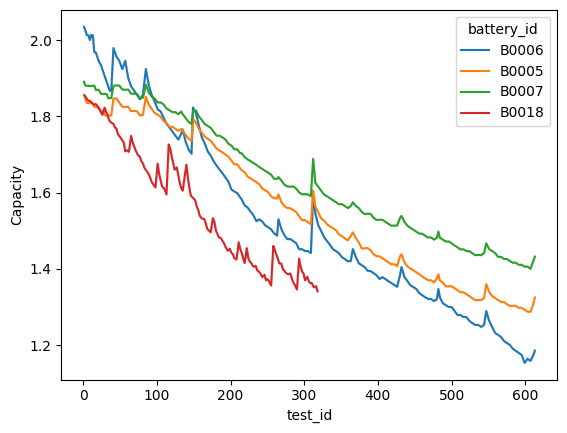

In [225]:
#Plotting the Change of capacity during cycles

sns.lineplot(B1_charge_discharge, x="test_id", y="Capacity", hue="battery_id")
plt.show()


- Not all batteries start with a capacity at the nominal value of 2 Ah.
    - SOH remains with the same nominal capacity
    - SOC can vary based on the first capacity

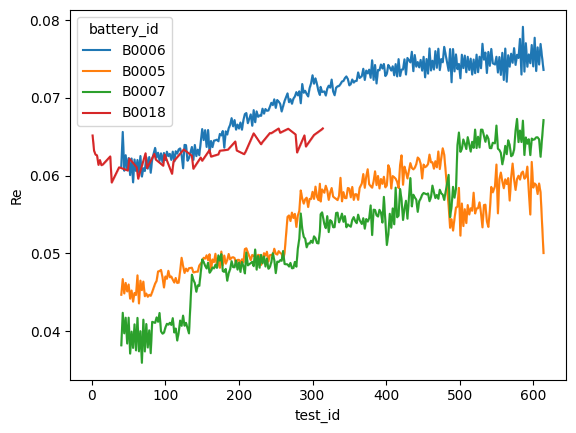

In [226]:
sns.lineplot(B1_impedance, x="test_id", y="Re", hue="battery_id")
plt.show()

# Data Visualization

## Charging

In [290]:
B1_charge = B1_charge_discharge.loc[B1_charge_discharge["type"]=="charge"]
B1_charge = B1_charge.sort_values(["battery_id", "test_id", "norm_time"])



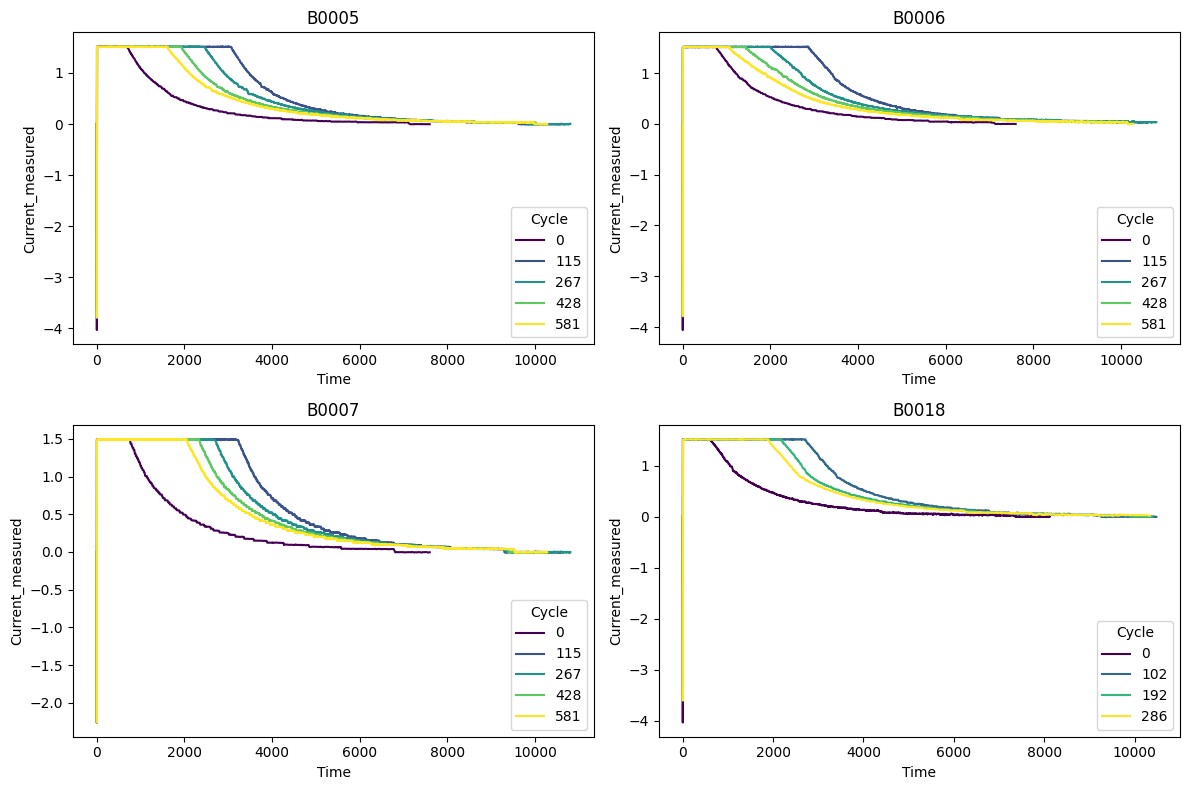

In [294]:
importlib.reload(utils)
from utils import visualization_2by2
visualization_2by2(B1_charge, "Time", "Current_measured")
plt.tight_layout()
plt.show()

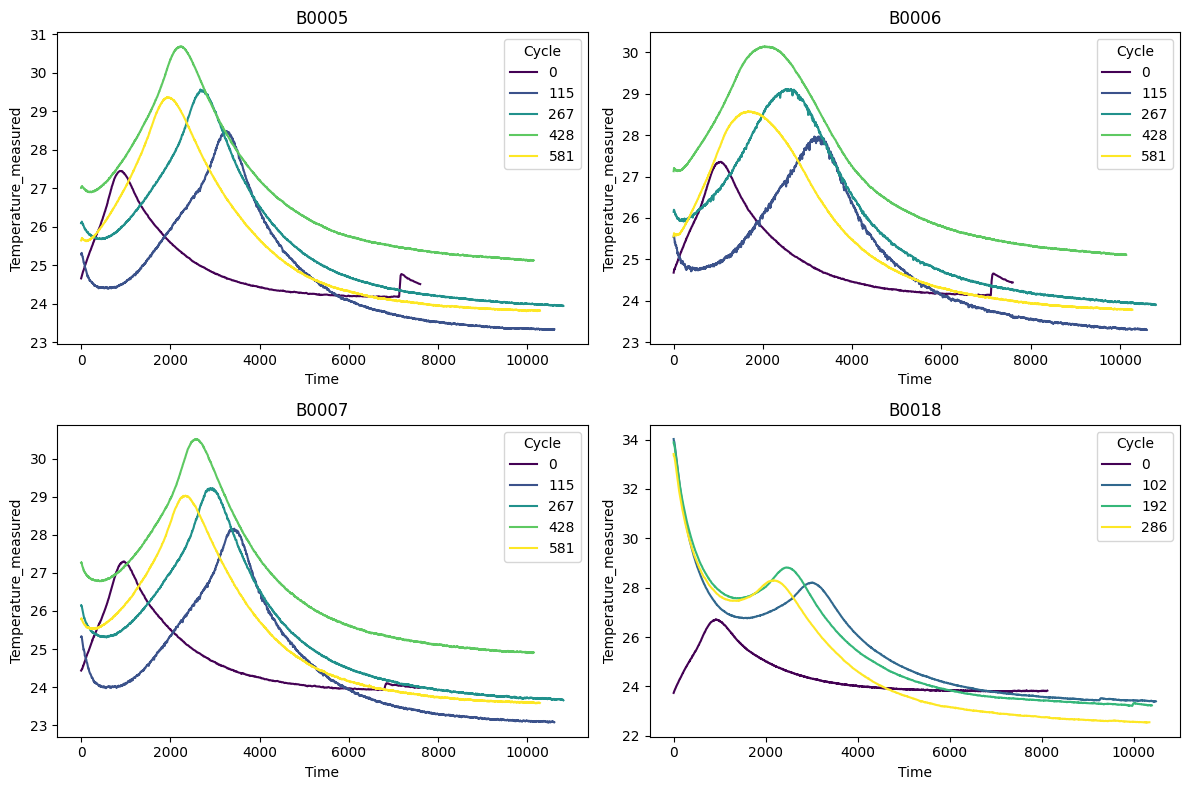

In [295]:
visualization_2by2(B1_charge, "Time", "Temperature_measured")
plt.tight_layout()
plt.show()

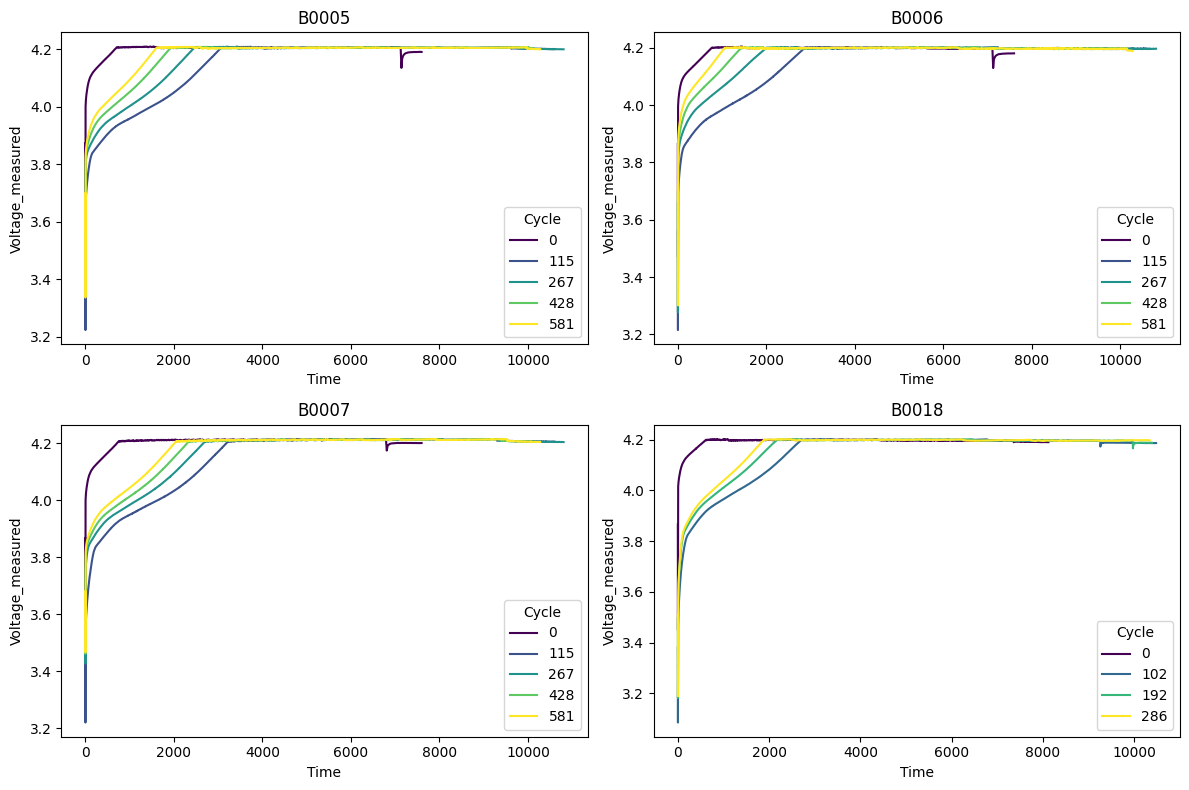

In [296]:

visualization_2by2(B1_charge, "Time", "Voltage_measured")
plt.tight_layout()
plt.show()

## Main observations from B0005

1. Cycle 0 is not representative for the following behavior of the battery as it has not yet been stabilized. 
2. the increase of temperature during charging is associated to the time it takes to reach 4.2 V and finish the constant current phase. 
3. With increasing cycles, the battery behavior changes to what would be the opposite of aging, and might be due to reconfiguration of the anode and cathode structures after cycling. One may have to analyze the impedance spectra. 

## actions: 
1. Calculate the time it takes to get to 4.2 V for each cycle. 
2. Time of maximum temperature vs time of 4.2 V to charge. 
3. Fit exponentially the curve of discharge to compare evolution of charging efficiency. 

Text(0, 0.5, 'Time to reach 4.2 V')

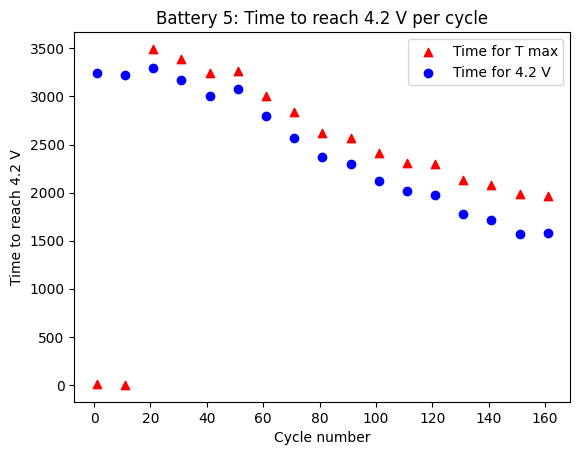

In [46]:
# Time for each cycle to get to 4.2 V, ignoring cycle 0
cycles = range(1,170,10)

for idx,i in enumerate(cycles):
    cycle = charge_dict["B0005"][i]
    filepath = cycle["filepath"]
    data = pd.read_csv(filepath)
    data["Time"] = data["Time"]-data["Time"].iloc[0]
    idx_42V = data.loc[data["Voltage_measured"]>=4.2].first_valid_index()
    t_42V = data["Time"].iloc[idx_42V]
    idx_Tmax = data.loc[data["Temperature_measured"]==data["Temperature_measured"].max()].first_valid_index()
    t_Tmax = data["Time"].iloc[idx_Tmax]
    t_charge = data["Time"].iloc[-1]-data["Time"].iloc[idx_42V]
    
    plt.scatter(i, t_Tmax, marker = '^', color ="red")
    plt.scatter(i, t_42V, marker ='o', color ="blue")

plt.title("Battery 5: Time to reach 4.2 V per cycle")
plt.legend(["Time for T max","Time for 4.2 V"])   
plt.xlabel("Cycle number")
plt.ylabel("Time to reach 4.2 V")




Text(0, 0.5, 'Time')

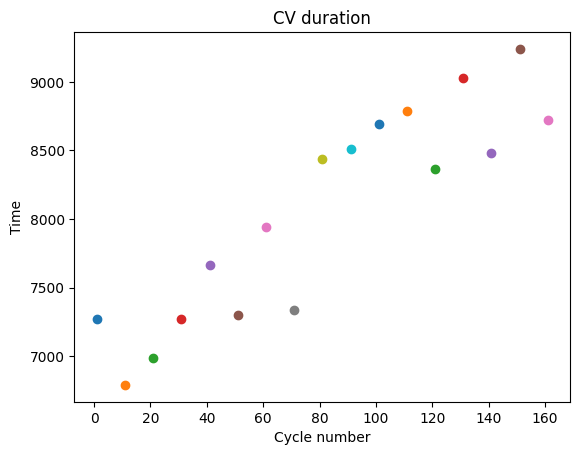

In [47]:
cycles = range(1,170,10)

for idx,i in enumerate(cycles):
    cycle = charge_dict["B0005"][i]
    filepath = cycle["filepath"]
    data = pd.read_csv(filepath)
    data["Time"] = data["Time"]-data["Time"].iloc[0]
    idx_42V = data.loc[data["Voltage_measured"]>=4.2].first_valid_index()
    t_42V = data["Time"].iloc[idx_42V]
    t_charge = data["Time"].iloc[-1]-t_42V
    plt.scatter(i, t_charge)
plt.title("CV duration") 
plt.xlabel("Cycle number")
plt.ylabel("Time")

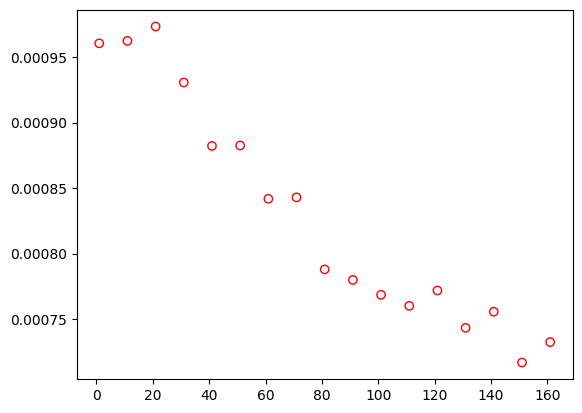

In [48]:
from scipy.optimize import curve_fit

def func(x, a, c, d):
    return a*np.exp(-c*x)+d

cycles = range(1,170,10)

for idx,i in enumerate(cycles):
    cycle = charge_dict["B0005"][i]
    filepath = cycle["filepath"]
    data = pd.read_csv(filepath)
    data["Time"] = data["Time"]-data["Time"].iloc[0]
    idx_42V = data.loc[data["Voltage_measured"]>=4.2].first_valid_index()
    CV_phase = data.iloc[idx_42V:]
    popt, pcov = curve_fit(func, CV_phase["Time"], CV_phase["Current_measured"], p0=(1, 1e-6, 1))
    #y = func(CV_phase["Time"],popt[0],popt[1],popt[2])
    plt.scatter(i,popt[1],facecolors='none', edgecolors='r')

## Features extracted from charging: 
1. Time it takes to reach 4.2 V
2. Time of max temperature
3. Exponential coefficient of the CV phase.

# Discharge

In [287]:
B1_discharge = B1_charge_discharge.loc[B1_charge_discharge["type"]=="discharge"]
B1_discharge


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,start_time,Capacity,Current_load,Voltage_load,real_time,norm_time
789,4.179800,-0.002366,24.277568,NaN,NaN,0.000,discharge,1,B0006,2008-04-02 15:25:41.593,2.035338,-0.0006,0.000,1.207150e+06,8.243672
790,4.179823,0.000434,24.277073,NaN,NaN,16.781,discharge,1,B0006,2008-04-02 15:25:41.593,2.035338,-0.0006,4.195,1.207167e+06,25.024672
791,3.966528,-2.014242,24.366226,NaN,NaN,35.703,discharge,1,B0006,2008-04-02 15:25:41.593,2.035338,-1.9990,3.070,1.207186e+06,43.946672
792,3.945886,-2.008730,24.515123,NaN,NaN,53.781,discharge,1,B0006,2008-04-02 15:25:41.593,2.035338,-1.9990,3.045,1.207204e+06,62.024672
793,3.930354,-2.013381,24.676053,NaN,NaN,71.922,discharge,1,B0006,2008-04-02 15:25:41.593,2.035338,-1.9990,3.026,1.207222e+06,80.165672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2089045,3.443760,-0.002426,35.383979,NaN,NaN,2686.359,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221908e+06,6474.192765
2089046,3.453271,-0.000981,35.179732,NaN,NaN,2700.546,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221922e+06,6488.379765
2089047,3.461963,0.000209,34.977000,NaN,NaN,2714.640,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221936e+06,6502.473765
2089048,3.469907,0.001516,34.785943,NaN,NaN,2728.750,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221950e+06,6516.583765


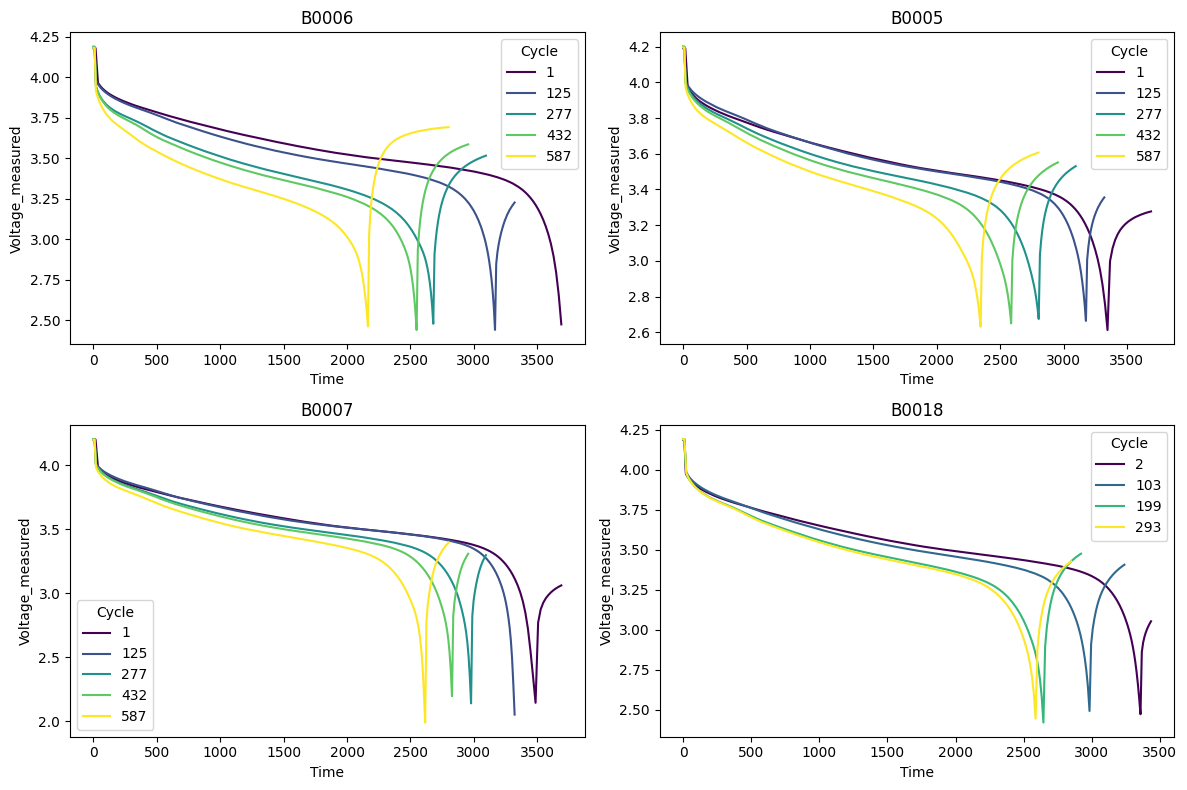

In [297]:
visualization_2by2(B1_discharge, "Time", "Voltage_measured")
plt.tight_layout()
plt.show()

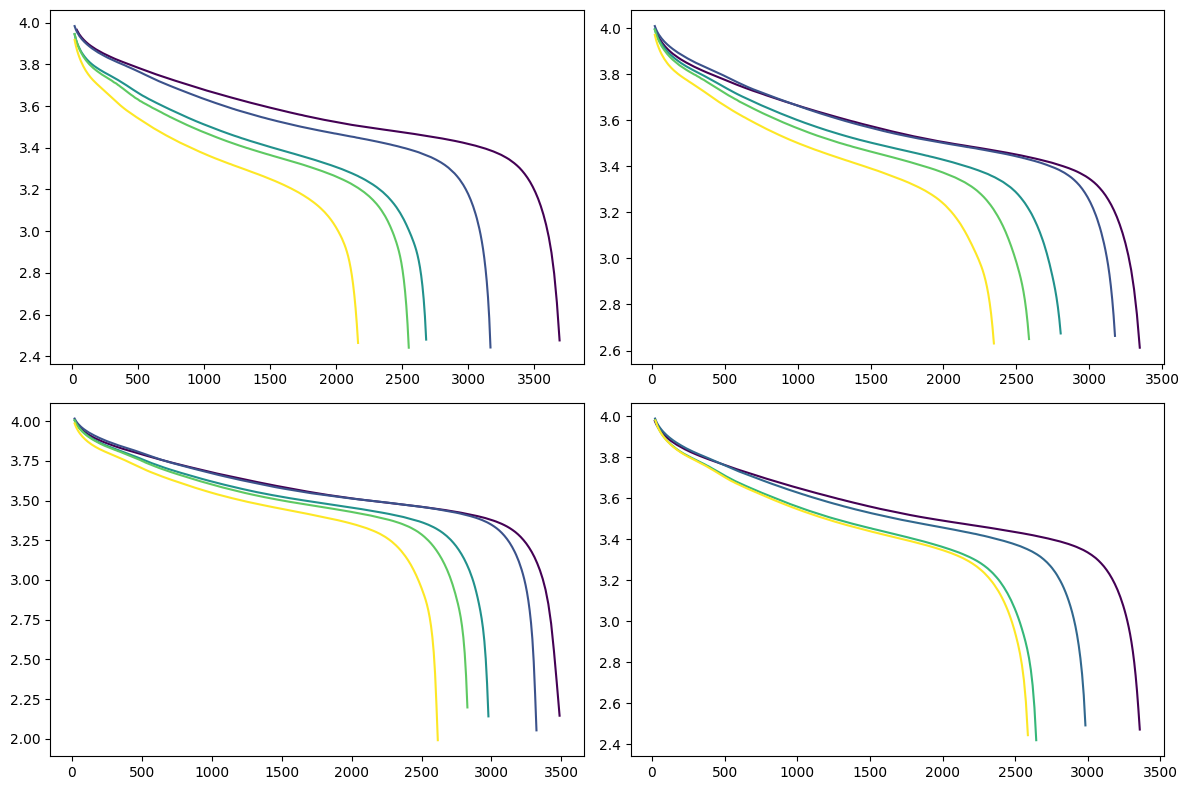

In [ ]:
# Ploting every 15th cycles from batteries B0005
import matplotlib as mpl
fig,ax = plt.subplots(2,2,figsize=(12,8))

ax = ax.flatten()

batteries = B1_discharge["battery_id"].unique()

cmap = plt.cm.viridis

for index,battery in enumerate(batteries):
    
    battery_df = B1_discharge[B1_discharge["battery_id"]==battery]
    
    cycles = battery_df["test_id"].unique()[::40]

    for j, cycle in enumerate(cycles):

        color = cmap(j / (len(cycles)-1))

        cycle_df = battery_df[battery_df["test_id"] == cycle].copy()

        # remove first transient points
        cycle_df = cycle_df.iloc[2:]
        threshold = -1.7
        mask = cycle_df.loc[cycle_df["Current_measured"]<threshold]

       
        ax[index].plot(
            mask["Time"],
            mask["Voltage_measured"],
            label=f"{cycle}",
            color=color)
plt.tight_layout()
plt.show()
    

In [299]:
#Changes on the capacity during discharge

    # Ensure proper ordering
B1_discharge_copy = B1_discharge.sort_values(["battery_id", "test_id", "norm_time"])
B1_discharge_copy.head(5)

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,start_time,Capacity,Current_load,Voltage_load,real_time,norm_time
592247,4.191492,-0.004902,24.330034,NaN,NaN,0.000,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,0.000,1.207150e+06,8.243672
592248,4.190749,-0.001478,24.325993,NaN,NaN,16.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,4.206,1.207167e+06,25.024672
592249,3.974871,-2.012528,24.389085,NaN,NaN,35.703,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.062,1.207186e+06,43.946672
592250,3.951717,-2.013979,24.544752,NaN,NaN,53.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.030,1.207204e+06,62.024672
592251,3.934352,-2.011144,24.731385,NaN,NaN,71.922,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.011,1.207222e+06,80.165672


In [300]:
#Time differential per battery using the normalized time
B1_discharge_copy["dt"]= B1_discharge_copy.groupby(["battery_id", "test_id"])["Time"].diff().fillna(0)
B1_discharge_copy["dQ"] = B1_discharge_copy["Current_measured"]*B1_discharge_copy["dt"]
B1_discharge_copy["capacity_Ah"] = B1_discharge_copy.groupby(["battery_id", "test_id"])["dQ"].cumsum()/3600

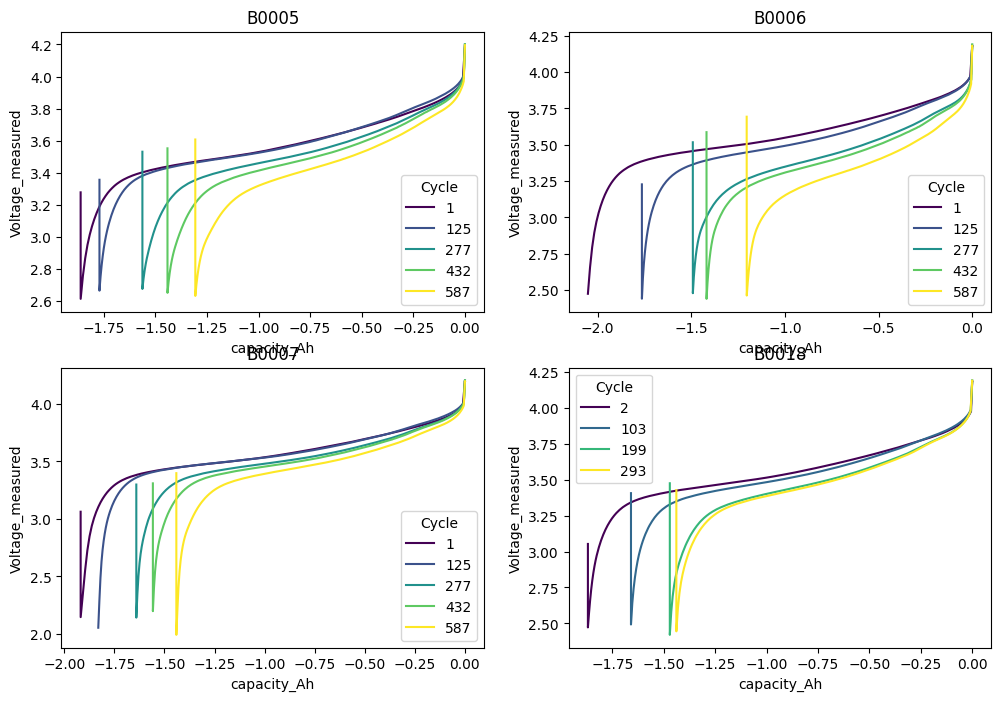

In [302]:
visualization_2by2(B1_discharge_copy,"capacity_Ah","Voltage_measured")
plt.show()

In [ ]:

    #Time differential per battery using the normalized time
    df["dt"]= df.groupby(["battery_id", "test_id"])["norm_time"].diff().fillna(0)
    
    #Incremental change in capacity
    df["dQ"] = df["Current_measured"]*df["dt"]
    
    #cumulative capacity

    df["capacity_Ah"] = df.groupby(["battery_id", "test_id"])["dQ"].cumsum()/3600
    df=df.drop(["dt","dQ"],axis=1)
    return df